# Day 5: Segment the Data (Clustering)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

## 1. Load Data

In [2]:
url = "https://raw.githubusercontent.com/Vvijayaragupathy-uno/machinelearning/main/day%205/CC%20GENERAL.csv"
data = pd.read_csv(url)

print(data.head())

  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.000000       

## 2. Understanding the Data (EDA)

In [ ]:
# Check how many rows and columns
print("Data Shape:")
print(data.shape)

# Check data types
print("\nData Info:")
print(data.info())

# Look at statistical summary (mean, min, max)
print("\nStatistical Summary:")
print(data.describe())

# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())

## 3. Visualizing Key Features (EDA)

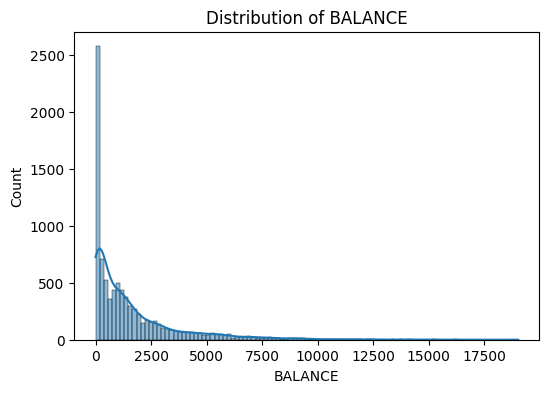

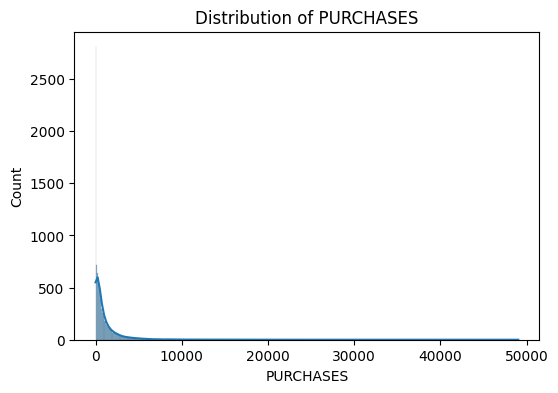

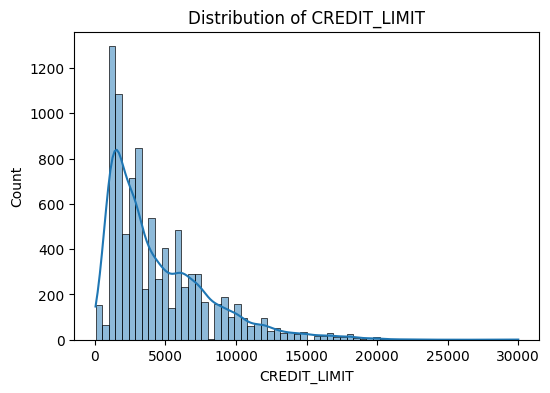

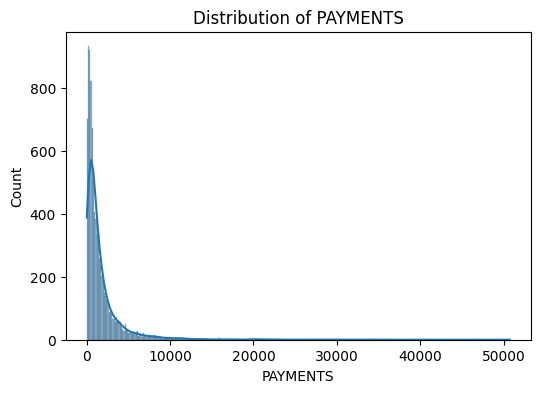

In [3]:
# Let's plot histograms for a few key columns to see how our data is distributed
columns_to_plot = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS']

for col in columns_to_plot:
    plt.figure(figsize=(6, 4))
    sns.histplot(data[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

## 4. Data Cleaning

In [4]:
# 1. Drop CUST_ID because it's just an ID text, not a useful number for math
data = data.drop(columns=['CUST_ID'])

# 2. We saw missing values in CREDIT_LIMIT and MINIMUM_PAYMENTS. Let's fill them with the median.
median_credit = data['CREDIT_LIMIT'].median()
data['CREDIT_LIMIT'] = data['CREDIT_LIMIT'].fillna(median_credit)

median_payment = data['MINIMUM_PAYMENTS'].median()
data['MINIMUM_PAYMENTS'] = data['MINIMUM_PAYMENTS'].fillna(median_payment)

print("\nMissing values after cleaning:")
print(data.isnull().sum().sum())


Missing values after cleaning:
0


## 5. Scale the Features

In [5]:
# Scaling is VERY important for clustering because it relies on distance!
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# Show a little bit of the scaled data
print("Scaled Data Shape:", scaled_data.shape)

Scaled Data Shape: (8950, 17)


## 6. The Elbow Method to pick 'k'

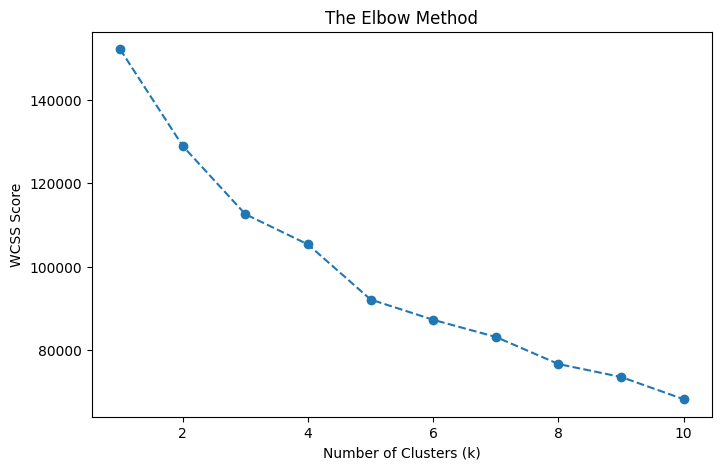

In [6]:
wcss = [] # Within-Cluster Sum of Squares

# Test k from 1 to 10
for i in range(1, 11):
    # n_init='auto' prevents a warning message
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS Score')
plt.show()

# Based on the graph, the elbow is around 4. We will pick k=4.

## 7. Apply K-Means and DBSCAN

In [7]:
# --- Apply K-Means ---
# We picked 4 clusters based on the elbow method
kmeans_model = KMeans(n_clusters=4, random_state=42, n_init='auto')
kmeans_clusters = kmeans_model.fit_predict(scaled_data)

# --- Apply DBSCAN ---
# eps: how close points must be to be neighbors. min_samples: core points needed
dbscan_model = DBSCAN(eps=2.0, min_samples=5)
dbscan_clusters = dbscan_model.fit_predict(scaled_data)

# Attach results to the original data so we can see them
data['KMeans_Cluster'] = kmeans_clusters
data['DBSCAN_Cluster'] = dbscan_clusters

print("K-Means finished. Total clusters:", len(set(kmeans_clusters)))
print("DBSCAN finished. Labels found:", set(dbscan_clusters))
print("(Note: In DBSCAN, -1 means 'Noise' or outlier)")

K-Means finished. Total clusters: 4
DBSCAN finished. Labels found: {np.int64(0), np.int64(1), np.int64(-1)}
(Note: In DBSCAN, -1 means 'Noise' or outlier)


## 8. PCA to Reduce Data to 2 Dimensions

In [8]:
# We have 17 features, we can't plot 17D. 
# PCA squishes all 17 features down into just 2 main components (X and Y).
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# Make a new DataFrame just for plotting
pca_df = pd.DataFrame(data=pca_data, columns=['PCA1', 'PCA2'])
pca_df['KMeans_Cluster'] = kmeans_clusters
pca_df['DBSCAN_Cluster'] = dbscan_clusters

print(pca_df.head())

       PCA1      PCA2  KMeans_Cluster  DBSCAN_Cluster
0 -1.683649 -1.072241               3               0
1 -1.134085  2.509150               0               0
2  0.969395 -0.383577               2               0
3 -0.888220  0.004648               3               0
4 -1.600021 -0.683795               3               0


## 9. Visualize the Clusters

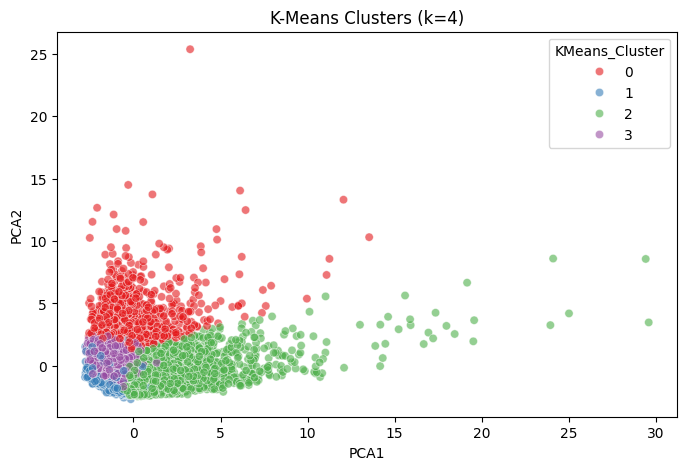

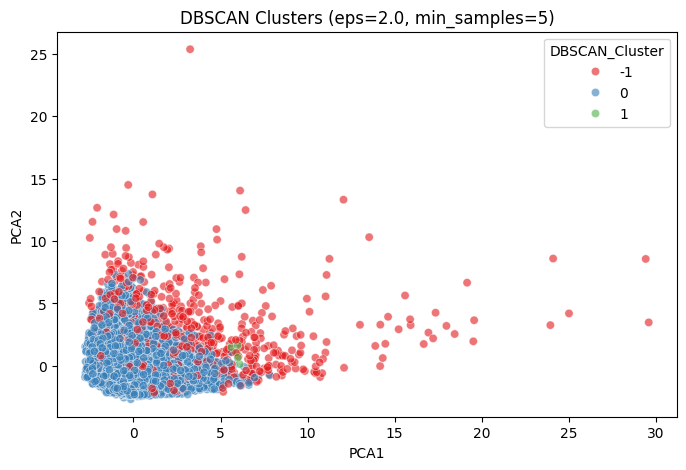

In [9]:
# Plot K-Means
plt.figure(figsize=(8, 5))
sns.scatterplot(x='PCA1', y='PCA2', hue='KMeans_Cluster', data=pca_df, palette='Set1', alpha=0.6)
plt.title('K-Means Clusters (k=4)')
plt.show()

# Plot DBSCAN
plt.figure(figsize=(8, 5))
sns.scatterplot(x='PCA1', y='PCA2', hue='DBSCAN_Cluster', data=pca_df, palette='Set1', alpha=0.6)
plt.title('DBSCAN Clusters (eps=2.0, min_samples=5)')
plt.show()

## 10. Cluster Analysis

Based on the **K-Means** clustering (k=4) on this credit card data, here is what each cluster typically represents:

*   **Cluster 0 (High Cash Advance Users)**: Customers who mostly use their cards for cash advances rather than purchases. They tend to have higher balances.
*   **Cluster 1 (Active Purchasers)**: Customers who frequently make purchases (often in installments) and pay off their balances quickly.
*   **Cluster 2 (Low Activity/Inactive)**: Customers with very low balances, low activity, and few transactions. These are the casual or inactive users.
*   **Cluster 3 (High Spenders/VIPs)**: Customers who are high spenders across all categories (both purchases and cash advances) and maintain high credit limits.

